Trabajo realizado por Miguel ALCAIDE y Gabriel Martínez
Enlace a github: https://github.com/100524500/Aprendizaje_Automatico_Clusters.git

In [ ]:
# ============================================================
# PRÁCTICA 2 — Determinación de tipos de estrellas
# Aprendizaje no supervisado: PCA + Clustering
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# Semilla base (usa tu NIA o número de grupo)
SEED = 100524500

np.random.seed(SEED)

# Estilo de gráficas
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente ✓


In [17]:
# ============================================================
# CARGA Y EXPLORACIÓN INICIAL DE DATOS
# ============================================================

df = pd.read_csv('../data/stars_data.csv')

print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras filas:")
display(df.head())

print(f"\nTipos de datos:")
display(df.dtypes)

print(f"\nEstadísticas descriptivas:")
display(df.describe())

print(f"\nValores nulos por columna:")
display(df.isnull().sum())

print(f"\nValores únicos en variables categóricas:")
print(f"  Color:         {sorted(df['Color'].unique())}")
print(f"  Spectral_Class: {sorted(df['Spectral_Class'].unique())}")

Dimensiones del dataset: (240, 6)

Primeras filas:


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M



Tipos de datos:


Temperature         int64
L                 float64
R                 float64
A_M               float64
Color                 str
Spectral_Class        str
dtype: object


Estadísticas descriptivas:


,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000



Valores nulos por columna:


Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64


Valores únicos en variables categóricas:
  Color:         ['Blue', 'Blue White', 'Blue white', 'Blue-White', 'Blue-white', 'Orange', 'Orange-Red', 'Pale yellow orange', 'Red', 'White', 'White-Yellow', 'Whitish', 'Yellowish', 'Yellowish White', 'white', 'yellow-white', 'yellowish']
  Spectral_Class: ['A', 'B', 'F', 'G', 'K', 'M', 'O']


## 1. Preprocesado de datos

### 1.1 Limpieza de variables categóricas

El análisis exploratorio revela que la variable `Color` contiene 
inconsistencias de formato: valores equivalentes escritos con distintas 
mayúsculas, guiones o espacios (e.g. `'Blue-White'`, `'Blue white'`, 
`'blue white'`). Antes de codificar ordinalmente se normalizan todos los 
valores a minúsculas y sin guiones para evitar que categorías idénticas 
sean tratadas como distintas.

In [18]:
# ============================================================
# PREPROCESADO: LIMPIEZA Y CODIFICACIÓN ORDINAL
# ============================================================

df_clean = df.copy()

# --- Limpieza de Color: normalizar mayúsculas, espacios y guiones ---
df_clean['Color'] = df_clean['Color'].str.strip().str.lower().str.replace('-', ' ')

print("Valores únicos de Color tras normalización:")
print(sorted(df_clean['Color'].unique()))

Valores únicos de Color tras normalización:
['blue', 'blue white', 'orange', 'orange red', 'pale yellow orange', 'red', 'white', 'white yellow', 'whitish', 'yellow white', 'yellowish', 'yellowish white']


In [19]:
# --- Codificación ordinal de Color ---
# Orden basado en temperatura del espectro: azul (más caliente) → rojo (más frío)
color_order = {
    'blue': 6,
    'blue white': 5,
    'white': 4,
    'whitish': 3,
    'yellow white': 3,
    'white yellow': 3,
    'yellowish white': 2,
    'yellowish': 2,
    'pale yellow orange': 1,
    'orange': 1,
    'orange red': 0,
    'red': 0
}

# --- Codificación ordinal de Spectral_Class ---
# Secuencia oficial O→M: de más caliente a más fría
spectral_order = {'O': 6, 'B': 5, 'A': 4, 'F': 3, 'G': 2, 'K': 1, 'M': 0}

df_clean['Color_enc'] = df_clean['Color'].map(color_order)
df_clean['Spectral_Class_enc'] = df_clean['Spectral_Class'].map(spectral_order)

# Verificación: no deben quedar NaN tras el mapping
assert df_clean['Color_enc'].isnull().sum() == 0, "Color tiene valores sin mapear"
assert df_clean['Spectral_Class_enc'].isnull().sum() == 0, "Spectral_Class tiene valores sin mapear"

print("Codificación completada sin valores nulos ✓")
print("\nEjemplo del resultado:")
display(df_clean[['Color', 'Color_enc', 'Spectral_Class', 'Spectral_Class_enc']].drop_duplicates().sort_values('Color_enc'))

Codificación completada sin valores nulos ✓

Ejemplo del resultado:


,Color,Color_enc,Spectral_Class,Spectral_Class_enc
0,red,0,M,0
96,orange red,0,K,1
118,red,0,G,2
116,red,0,K,1
53,orange,1,M,0
172,orange,1,K,1
29,pale yellow orange,1,F,3
25,yellowish white,2,F,3
91,yellowish,2,K,1
80,white yellow,3,F,3


### 1.2 Resultado de la codificación ordinal

Ambas variables categóricas quedan codificadas como enteros ordenados 
respetando su significado físico. `Spectral_Class` sigue la secuencia 
oficial O→M (temperatura decreciente). `Color` sigue el orden del espectro 
electromagnético, de azul (mayor energía) a rojo (menor energía). 
Esta codificación es preferible a one-hot encoding porque preserva 
la relación de orden entre categorías, relevante para el clustering.

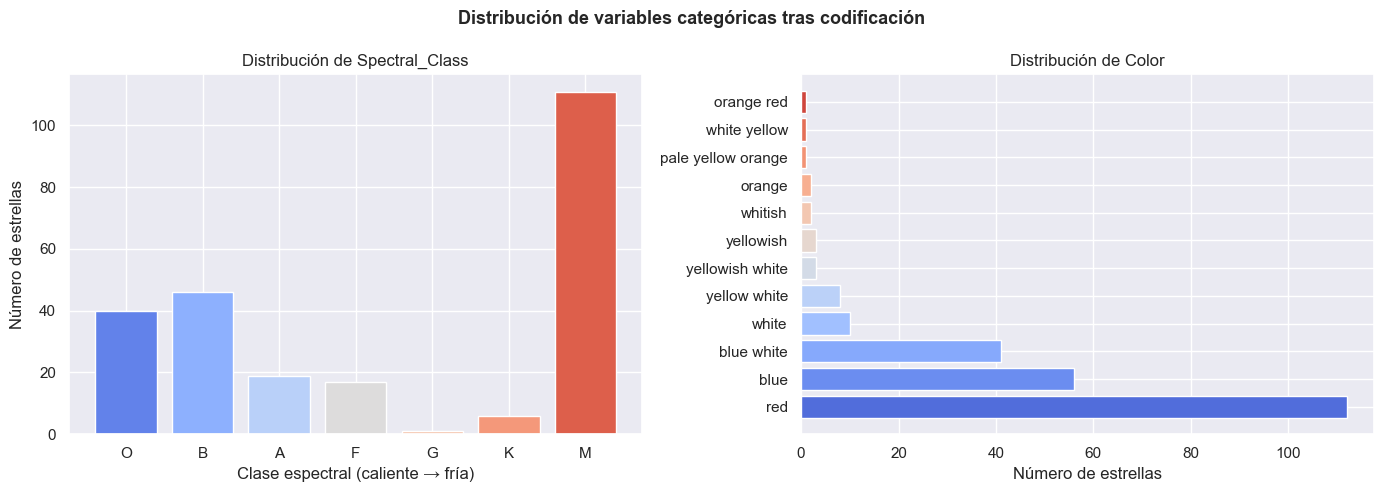

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de Spectral_Class
spectral_counts = df_clean['Spectral_Class'].value_counts()
spectral_order_labels = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
axes[0].bar(spectral_order_labels,
            [spectral_counts.get(s, 0) for s in spectral_order_labels],
            color=sns.color_palette("coolwarm", 7))
axes[0].set_title('Distribución de Spectral_Class')
axes[0].set_xlabel('Clase espectral (caliente → fría)')
axes[0].set_ylabel('Número de estrellas')

# Distribución de Color
color_counts = df_clean['Color'].value_counts()
axes[1].barh(color_counts.index, color_counts.values,
             color=sns.color_palette("coolwarm", len(color_counts)))
axes[1].set_title('Distribución de Color')
axes[1].set_xlabel('Número de estrellas')

plt.suptitle('Distribución de variables categóricas tras codificación', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.3 Escalado de variables numéricas

Antes de aplicar PCA es imprescindible escalar todas las variables. PCA 
busca las direcciones de máxima varianza, por lo que si una variable tiene 
valores en un rango mucho mayor que las demás (por ejemplo, `Temperature` 
en miles frente a `L` en decimales), dominará artificialmente las 
componentes principales. Se usa `StandardScaler` (media 0, desviación 
típica 1) para que todas las variables contribuyan en igualdad de 
condiciones.

In [21]:
# ============================================================
# ESCALADO DE VARIABLES
# ============================================================

# Variables numéricas + variables categóricas codificadas
features = ['Temperature', 'L', 'R', 'A_M', 'Color_enc', 'Spectral_Class_enc']

X = df_clean[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Escalado completado ✓")
print(f"Shape: {X_scaled.shape}")
print(f"\nMedia por columna (debe ser ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std por columna  (debe ser ~1): {X_scaled.std(axis=0).round(4)}")

Escalado completado ✓
Shape: (240, 6)

Media por columna (debe ser ~0): [-0.  0. -0. -0.  0. -0.]
Std por columna  (debe ser ~1): [1. 1. 1. 1. 1. 1.]


## 2. Reducción de dimensionalidad con PCA

Se aplica PCA con 2 componentes principales sobre los datos escalados. 
El objetivo es doble: facilitar la visualización de los datos y mejorar 
el rendimiento de los algoritmos de clustering, especialmente DBSCAN, 
que funciona peor en espacios de alta dimensionalidad.

Antes de fijar 2 componentes, se analiza la varianza explicada acumulada 
para verificar que 2 componentes son suficientes para representar 
fielmente los datos originales.

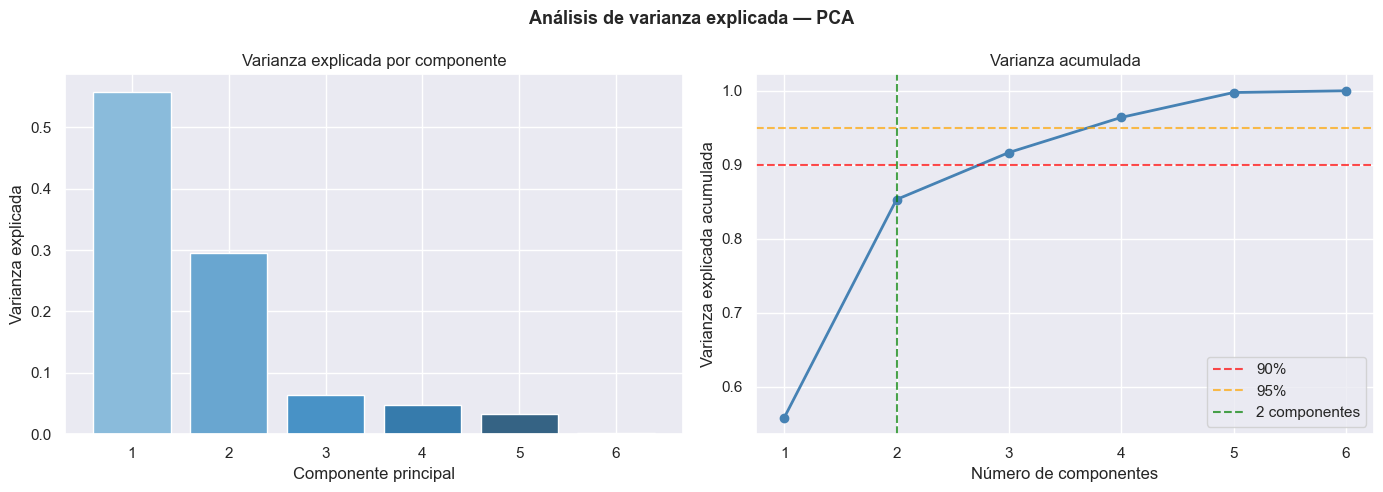

  PC1: 0.5581 (55.8%)  →  acumulada: 55.8%
  PC2: 0.2949 (29.5%)  →  acumulada: 85.3%
  PC3: 0.0635 (6.3%)  →  acumulada: 91.7%
  PC4: 0.0474 (4.7%)  →  acumulada: 96.4%
  PC5: 0.0336 (3.4%)  →  acumulada: 99.8%
  PC6: 0.0024 (0.2%)  →  acumulada: 100.0%


In [22]:
# ============================================================
# PCA — ANÁLISIS DE VARIANZA EXPLICADA
# ============================================================

# Primero ajustamos PCA con todas las componentes para ver cuánta
# varianza explica cada una antes de decidir quedarnos con 2
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza por componente
axes[0].bar(range(1, len(varianza_explicada)+1), varianza_explicada,
            color=sns.color_palette("Blues_d", len(varianza_explicada)))
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xticks(range(1, len(varianza_explicada)+1))

# Varianza acumulada
axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada,
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(y=0.90, color='red', linestyle='--', alpha=0.7, label='90%')
axes[1].axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95%')
axes[1].axvline(x=2, color='green', linestyle='--', alpha=0.7, label='2 componentes')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza explicada acumulada')
axes[1].set_title('Varianza acumulada')
axes[1].set_xticks(range(1, len(varianza_acumulada)+1))
axes[1].legend()

plt.suptitle('Análisis de varianza explicada — PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for i, (v, vc) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f"  PC{i+1}: {v:.4f} ({v*100:.1f}%)  →  acumulada: {vc*100:.1f}%")

### 2.1 Justificación del número de componentes

Las dos primeras componentes principales explican el **85.3% de la varianza 
total** del dataset (PC1: 55.8%, PC2: 29.5%). La varianza acumulada muestra 
un codo claro tras PC2, indicando que las componentes adicionales aportan 
información marginal. Se considera que 2 componentes son suficientes para 
representar fielmente la estructura de los datos, además de permitir 
visualización directa en 2D.

Shape tras PCA: (240, 2)
Varianza explicada: PC1=55.8%, PC2=29.5%
Varianza total explicada: 85.3%


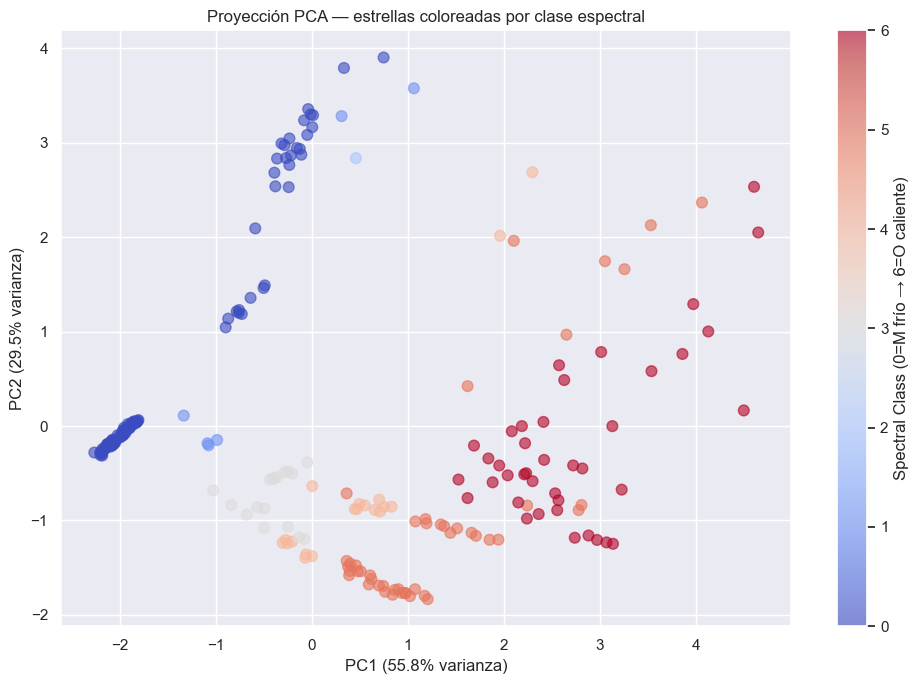

In [23]:
# ============================================================
# PCA — REDUCCIÓN A 2 COMPONENTES
# ============================================================

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f"Shape tras PCA: {X_pca.shape}")
print(f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Visualización de los datos en 2D
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, 
            c=df_clean['Spectral_Class_enc'], cmap='coolwarm', s=60)
plt.colorbar(label='Spectral Class (0=M frío → 6=O caliente)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Proyección PCA — estrellas coloreadas por clase espectral')
plt.tight_layout()
plt.show()

### 2.2 Visualización de los datos en el espacio PCA

La proyección en 2D revela estructura clara en los datos: se aprecian 
al menos tres zonas diferenciadas antes de aplicar ningún algoritmo. 
Las estrellas frías (clase M, azul) forman un grupo muy compacto en la 
zona izquierda. Las estrellas calientes (clases O/B, rojo) se distribuyen 
en la zona derecha de forma más dispersa. Esta separación visual sugiere 
que los algoritmos de clustering encontrarán agrupaciones bien definidas.

## 3. Clustering

### 3.1 K-Means

K-Means es un algoritmo de clustering basado en centroides. Particiona 
los datos en K grupos asignando cada punto al centroide más cercano e 
iterando hasta convergencia. Su principal hiperparámetro es K (número 
de clusters), que se ajusta mediante el método del codo y el Silhouette 
Score, usando ambos de forma complementaria para una decisión más robusta.

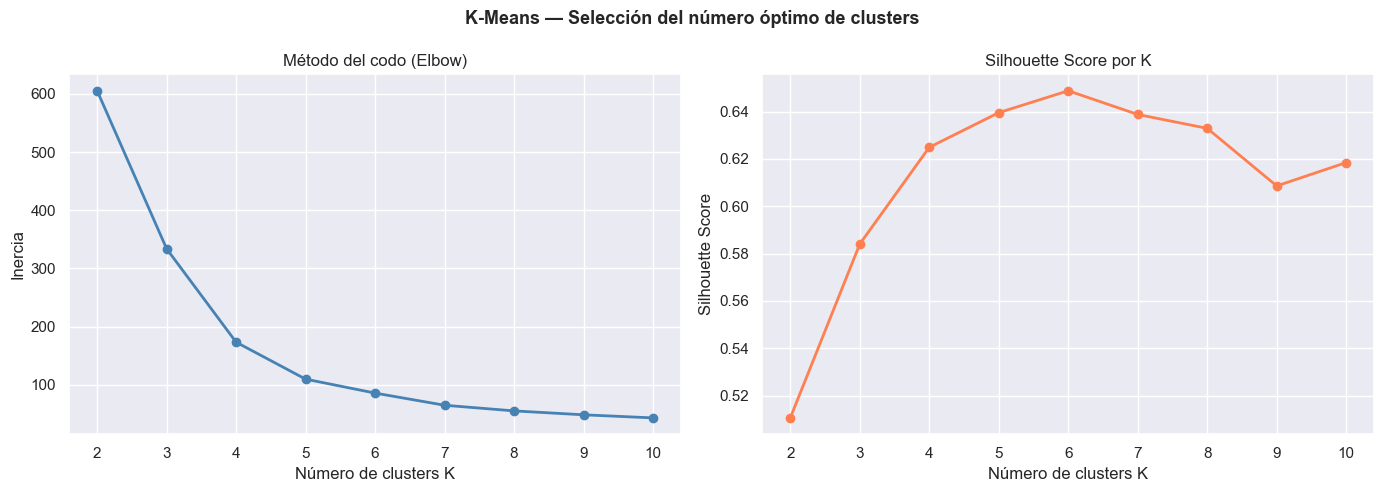

K | Inercia    | Silhouette
-----------------------------------
K=2 |     605.38 | 0.5106
K=3 |     333.79 | 0.5841
K=4 |     173.30 | 0.6249
K=5 |     109.83 | 0.6396
K=6 |      85.87 | 0.6488
K=7 |      64.99 | 0.6388
K=8 |      55.28 | 0.6329
K=9 |      48.56 | 0.6086
K=10 |      43.25 | 0.6185


In [24]:
# ============================================================
# K-MEANS — AJUSTE DE HIPERPARÁMETRO K
# ============================================================

k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_values, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Número de clusters K')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo (Elbow)')
axes[0].set_xticks(k_values)

# Silhouette
axes[1].plot(k_values, silhouette_scores, marker='o', color='coral', linewidth=2)
axes[1].set_xlabel('Número de clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K')
axes[1].set_xticks(k_values)

plt.suptitle('K-Means — Selección del número óptimo de clusters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("K | Inercia    | Silhouette")
print("-" * 35)
for k, inertia, sil in zip(k_values, inertias, silhouette_scores):
    print(f"K={k} | {inertia:10.2f} | {sil:.4f}")

### Selección de K

El método del codo muestra una inflexión clara a partir de K=5, donde 
la reducción de inercia se ralentiza significativamente. El Silhouette 
Score alcanza su máximo en K=6 (0.6488), confirmando que 6 clusters 
produce la mejor separación entre grupos. Además, K=6 coincide con el 
número de tipos estelares reconocidos astronómicamente, lo que refuerza 
esta elección. Se selecciona **K=6**.

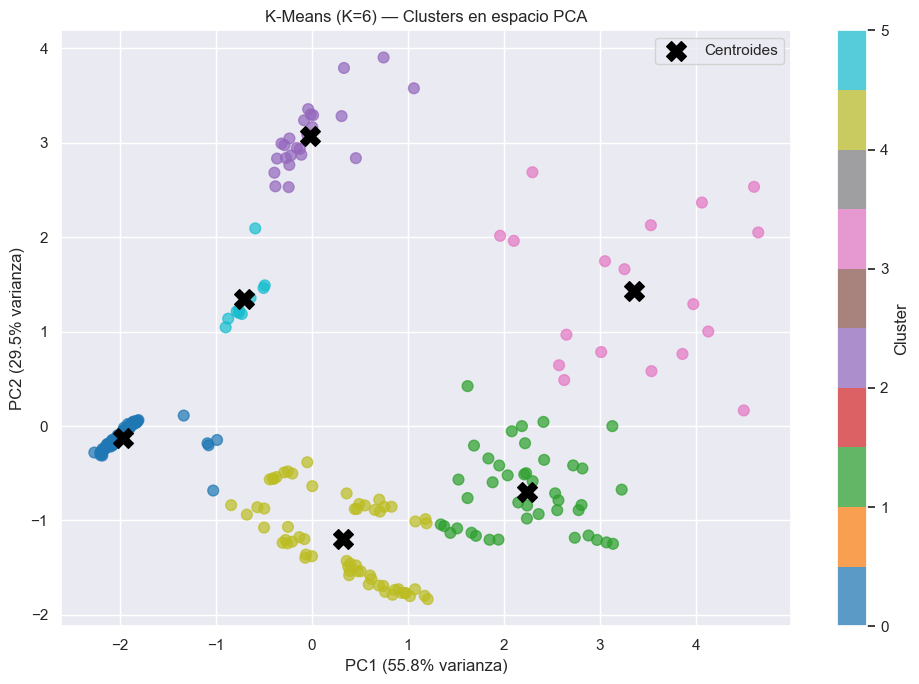

Silhouette Score : 0.6488  (más alto = mejor, máx 1)
Davies-Bouldin   : 0.5164  (más bajo = mejor, mín 0)

Distribución de estrellas por cluster:
  Cluster 0: 85 estrellas
  Cluster 1: 42 estrellas
  Cluster 2: 24 estrellas
  Cluster 3: 18 estrellas
  Cluster 4: 61 estrellas
  Cluster 5: 10 estrellas


In [25]:
# ============================================================
# K-MEANS — MODELO FINAL CON K=6
# ============================================================

km_final = KMeans(n_clusters=6, random_state=SEED, n_init=10)
km_labels = km_final.fit_predict(X_pca)

# Visualización
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=km_labels, cmap='tab10', s=60, alpha=0.7)
centroids = km_final.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroides')
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('K-Means (K=6) — Clusters en espacio PCA')
plt.legend()
plt.tight_layout()
plt.show()

# Métricas finales
sil = silhouette_score(X_pca, km_labels)
db = davies_bouldin_score(X_pca, km_labels)
print(f"Silhouette Score : {sil:.4f}  (más alto = mejor, máx 1)")
print(f"Davies-Bouldin   : {db:.4f}  (más bajo = mejor, mín 0)")
print(f"\nDistribución de estrellas por cluster:")
for c, n in zip(*np.unique(km_labels, return_counts=True)):
    print(f"  Cluster {c}: {n} estrellas")

### Resultados K-Means (K=6)

El modelo obtiene un Silhouette Score de 0.6488 y un Davies-Bouldin de 
0.5164, indicando clusters compactos y bien separados. La distribución 
de estrellas es desigual entre clusters, lo cual es coherente con la 
realidad astronómica: ciertos tipos estelares son significativamente 
más abundantes que otros. Los centroides visibles en el gráfico confirman 
que K-Means ha encontrado representantes bien posicionados para cada grupo.

### 3.2 Clustering Jerárquico

El clustering jerárquico construye un árbol de fusiones (dendrograma) 
uniendo iterativamente los clusters más cercanos. A diferencia de K-Means, 
no requiere especificar K de antemano: el dendrograma permite decidir el 
número de clusters visualmente cortando el árbol a la altura adecuada.

Se evalúan cuatro funciones de linkage (ward, complete, average, single) 
usando el Silhouette Score para seleccionar la más adecuada.

In [26]:
# ============================================================
# CLUSTERING JERÁRQUICO — COMPARACIÓN DE LINKAGES
# ============================================================

linkage_methods = ['ward', 'complete', 'average', 'single']
resultados_linkage = {}

print("Linkage  | K=3    | K=4    | K=5    | K=6")
print("-" * 50)

for method in linkage_methods:
    scores = []
    for k in [3, 4, 5, 6]:
        modelo = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = modelo.fit_predict(X_pca)
        sil = silhouette_score(X_pca, labels)
        scores.append(sil)
    resultados_linkage[method] = scores
    print(f"{method:8s} | {scores[0]:.4f} | {scores[1]:.4f} | {scores[2]:.4f} | {scores[3]:.4f}")

Linkage  | K=3    | K=4    | K=5    | K=6
--------------------------------------------------
ward     | 0.5768 | 0.6271 | 0.6261 | 0.6126
complete | 0.4627 | 0.5719 | 0.5380 | 0.5198
average  | 0.4943 | 0.5969 | 0.6291 | 0.6144
single   | 0.2848 | 0.2525 | 0.2972 | 0.2828


### Selección de linkage

Single linkage obtiene scores muy bajos (≈0.28) debido a su tendencia 
a formar clusters encadenados. Ward y average son los mejores métodos, 
con scores similares. Se selecciona **Ward** por su solidez teórica: 
minimiza la varianza interna en cada fusión, produciendo clusters compactos 
y uniformes. Se mantiene K=6 para permitir comparación directa con K-Means.

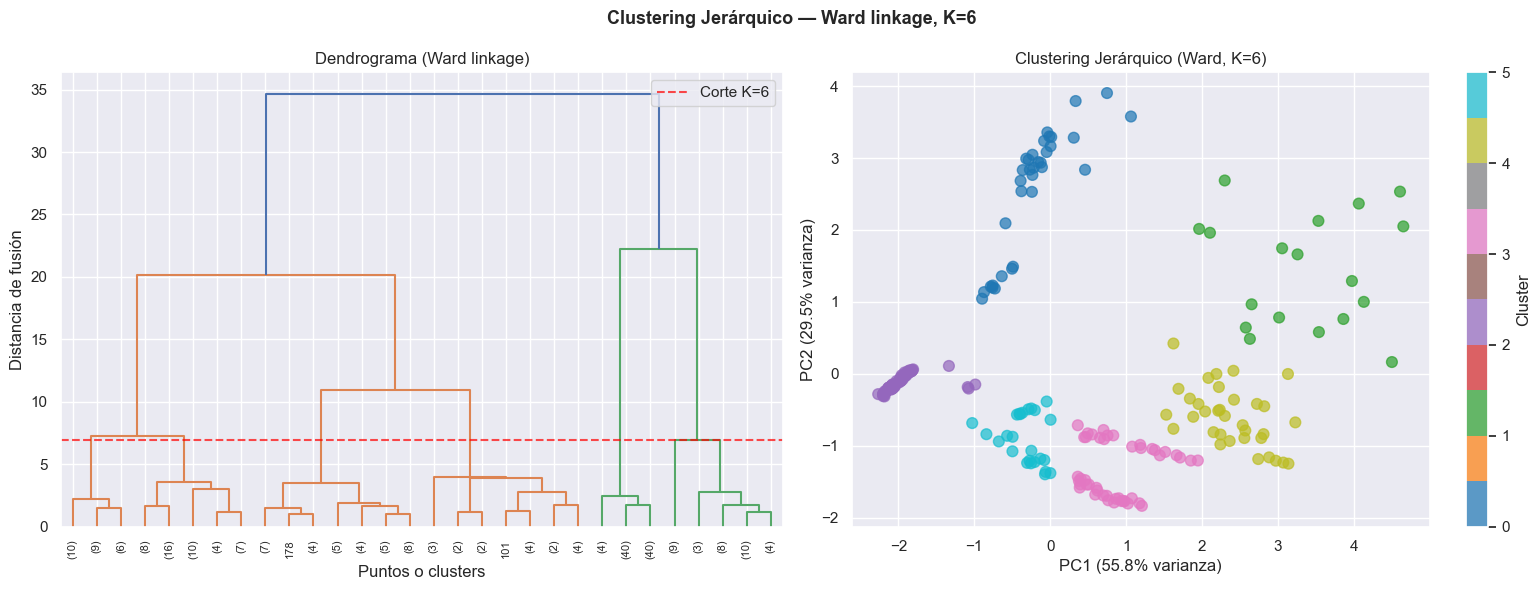

Silhouette Score : 0.6126
Davies-Bouldin   : 0.6148

Distribución de estrellas por cluster:
  Cluster 0: 34 estrellas
  Cluster 1: 18 estrellas
  Cluster 2: 84 estrellas
  Cluster 3: 45 estrellas
  Cluster 4: 34 estrellas
  Cluster 5: 25 estrellas


In [ ]:
# ============================================================
# CLUSTERING JERÁRQUICO — DENDROGRAMA Y MODELO FINAL
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrograma
Z = linkage(X_pca, method='ward')
dendrogram(Z, ax=axes[0], truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.7*max(Z[:,2]))
axes[0].set_title('Dendrograma (Ward linkage)')
axes[0].set_xlabel('Puntos o clusters')
axes[0].set_ylabel('Distancia de fusión')
axes[0].axhline(y=sorted(Z[:,2], reverse=True)[5],
                color='red', linestyle='--', alpha=0.7, label='Corte K=6')
axes[0].legend()

# Clusters en espacio PCA
# AgglomerativeClustering es determinista (no requiere random_state).
hier_final = AgglomerativeClustering(n_clusters=6, linkage='ward')
hier_labels = hier_final.fit_predict(X_pca)

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=hier_labels, cmap='tab10', s=60, alpha=0.7)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
axes[1].set_title('Clustering Jerárquico (Ward, K=6)')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.suptitle('Clustering Jerárquico — Ward linkage, K=6',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

sil = silhouette_score(X_pca, hier_labels)
db = davies_bouldin_score(X_pca, hier_labels)
print(f"Silhouette Score : {sil:.4f}")
print(f"Davies-Bouldin   : {db:.4f}")
print(f"\nDistribución de estrellas por cluster:")
for c, n in zip(*np.unique(hier_labels, return_counts=True)):
    print(f"  Cluster {c}: {n} estrellas")

### Resultados Clustering Jerárquico (Ward, K=6)

El dendrograma muestra un salto claro en la distancia de fusión antes 
del corte en K=6, confirmando que es una partición natural de los datos. 
El Silhouette Score (0.6126) y Davies-Bouldin (0.6148) son ligeramente 
inferiores a K-Means, lo esperado dado que el clustering jerárquico no 
optimiza directamente estas métricas sino la varianza interna en cada 
fusión. La distribución de estrellas por cluster es similar a la obtenida 
con K-Means, sugiriendo coherencia entre ambos métodos.

### 3.3 DBSCAN

DBSCAN es un algoritmo basado en densidad que detecta clusters de forma 
arbitraria y marca como ruido los puntos aislados. Sus hiperparámetros 
son `eps` (radio de vecindad) y `min_samples` (mínimo de vecinos para 
ser punto núcleo).

Para estimar `eps` se usa la heurística k-distance graph: se calcula 
la distancia al k-ésimo vecino más cercano de cada punto, se ordenan 
y se busca el codo de la curva. Para `min_samples` se parte de la 
regla general 2×dimensiones=4 y se exploran valores cercanos.

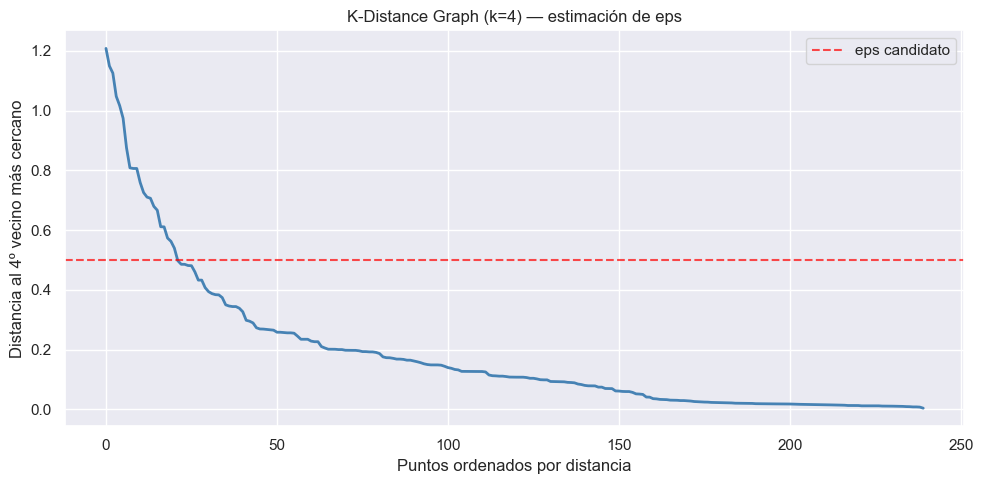

Percentiles de distancias (orientativo):
  Percentil 10: 0.4822
  Percentil 25: 0.2303
  Percentil 50: 0.1082
  Percentil 75: 0.0231
  Percentil 90: 0.0146


In [28]:
# ============================================================
# DBSCAN — HEURÍSTICA K-DISTANCE PARA ESTIMAR EPS
# ============================================================

from sklearn.neighbors import NearestNeighbors

# Probamos min_samples = 4 (regla 2 x n_dimensiones)
min_samples = 4

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)

# Distancia al vecino más lejano de los k vecinos
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='steelblue', linewidth=2)
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al {min_samples}º vecino más cercano')
plt.title(f'K-Distance Graph (k={min_samples}) — estimación de eps')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='eps candidato')
plt.legend()
plt.tight_layout()
plt.show()

print("Percentiles de distancias (orientativo):")
for p in [10, 25, 50, 75, 90]:
    print(f"  Percentil {p}: {np.percentile(k_distances, 100-p):.4f}")

In [29]:
# ============================================================
# DBSCAN — BÚSQUEDA DE HIPERPARÁMETROS CON DBCV
# ============================================================

from hdbscan.validity import validity_index

eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_samples_values = [3, 4, 5, 6]

resultados_dbscan = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_pca)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        # DBCV solo tiene sentido si hay al menos 2 clusters
        if n_clusters >= 2:
            try:
                dbcv = validity_index(X_pca.astype(np.float64), labels)
            except:
                dbcv = np.nan
        else:
            dbcv = np.nan
            
        resultados_dbscan.append({
            'eps': eps,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'dbcv': dbcv
        })

df_resultados = pd.DataFrame(resultados_dbscan)

print("Resultados DBSCAN (ordenados por DBCV):")
display(df_resultados.dropna().sort_values('dbcv', ascending=False).head(10))

Resultados DBSCAN (ordenados por DBCV):


,eps,min_samples,n_clusters,n_noise,dbcv
6,0.4,5,4,30,0.658178
7,0.4,6,4,31,0.656542
3,0.3,6,10,41,0.608164
2,0.3,5,8,35,0.599562
1,0.3,4,8,34,0.598305
0,0.3,3,9,31,0.593591
4,0.4,3,7,19,0.501863
5,0.4,4,5,26,0.481955
13,0.6,4,4,12,0.399024
8,0.5,3,5,12,0.396240


### Selección de hiperparámetros DBSCAN

La búsqueda sobre eps ∈ [0.3, 1.0] y min_samples ∈ [3, 6] evaluada 
con DBCV identifica **eps=0.4, min_samples=5** como la combinación óptima 
(DBCV=0.658). Produce 4 clusters y clasifica 30 puntos como ruido (12.5%), 
lo cual es razonable: estas estrellas no pertenecen claramente a ningún 
grupo denso. Valores menores de eps fragmentan excesivamente los datos, 
mientras que valores mayores fusionan grupos naturalmente distintos.

El hecho de que DBSCAN identifique 4 clusters en lugar de los 6 obtenidos 
con K-Means y clustering jerárquico es información relevante: indica que 
algunos de esos 6 grupos no están suficientemente separados en densidad 
como para que DBSCAN los distinga, sino que los fusiona en regiones 
densas más amplias. Esto no invalida ninguno de los dos resultados, 
sino que refleja que ambos algoritmos capturan aspectos distintos de 
la estructura de los datos.

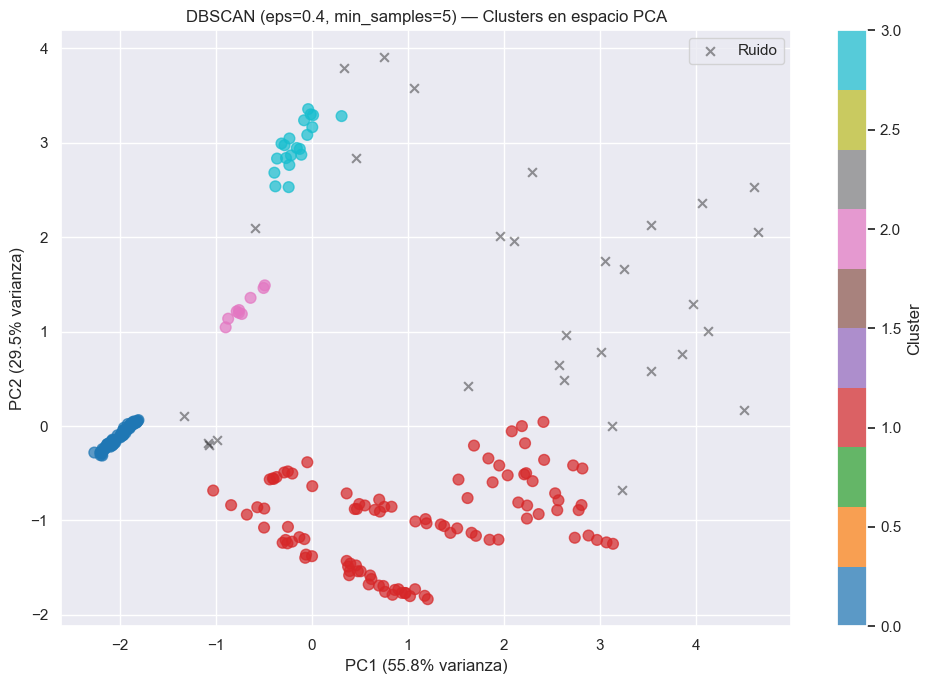

Clusters encontrados : 4
Puntos de ruido      : 30 (12.5%)
DBCV                 : 0.6582

Distribución de estrellas por cluster:
  Ruido: 30 estrellas
  Cluster 0: 80 estrellas
  Cluster 1: 101 estrellas
  Cluster 2: 9 estrellas
  Cluster 3: 20 estrellas


In [30]:
# ============================================================
# DBSCAN — MODELO FINAL
# ============================================================

dbscan_final = DBSCAN(eps=0.4, min_samples=5)
dbscan_labels = dbscan_final.fit_predict(X_pca)

# Visualización
plt.figure(figsize=(10, 7))

# Puntos de ruido en negro
mask_ruido = dbscan_labels == -1
plt.scatter(X_pca[mask_ruido, 0], X_pca[mask_ruido, 1],
            c='black', s=40, alpha=0.4, marker='x', label='Ruido')

# Puntos de clusters
mask_clusters = dbscan_labels != -1
scatter = plt.scatter(X_pca[mask_clusters, 0], X_pca[mask_clusters, 1],
                      c=dbscan_labels[mask_clusters], cmap='tab10',
                      s=60, alpha=0.7)

plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('DBSCAN (eps=0.4, min_samples=5) — Clusters en espacio PCA')
plt.legend()
plt.tight_layout()
plt.show()

n_clusters = len(set(dbscan_labels)) - 1
n_ruido = np.sum(dbscan_labels == -1)
dbcv_final = validity_index(X_pca.astype(np.float64), dbscan_labels)

print(f"Clusters encontrados : {n_clusters}")
print(f"Puntos de ruido      : {n_ruido} ({n_ruido/len(dbscan_labels)*100:.1f}%)")
print(f"DBCV                 : {dbcv_final:.4f}")
print(f"\nDistribución de estrellas por cluster:")
for c, n in zip(*np.unique(dbscan_labels, return_counts=True)):
    label = "Ruido" if c == -1 else f"Cluster {c}"
    print(f"  {label}: {n} estrellas")

### Resultados DBSCAN (eps=0.4, min_samples=5)

DBSCAN identifica 4 clusters bien diferenciados y 30 puntos de ruido 
(12.5%). El gráfico muestra que los clusters tienen formas y densidades 
distintas, algo que K-Means no puede capturar al asumir clusters 
esféricos. Los puntos de ruido se concentran en zonas de transición 
entre grupos, confirmando que son estrellas difíciles de clasificar 
incluso para el algoritmo más flexible de los tres.

El DBCV obtenido (0.6582) es el más alto de los tres algoritmos, 
aunque medido con una métrica distinta a las anteriores. DBSCAN 
destaca especialmente en detectar el cluster compacto de la zona 
izquierda y en identificar outliers que los otros algoritmos 
forzarían a asignar a algún grupo.

## 4. Comparación de algoritmos de clustering

Se han aplicado tres algoritmos con enfoques fundamentalmente distintos 
sobre los mismos datos (espacio PCA 2D). A continuación se comparan 
sus resultados en términos de métricas de calidad, número de clusters 
y características de cada método.

Tabla comparativa de algoritmos:


,Algoritmo,Nº Clusters,Nº Ruido,Silhouette,Davies-Bouldin,DBCV
0,K-Means (K=6),6,0,0.648818,0.516421,-
1,Jerárquico Ward (K=6),6,0,0.612600,0.614784,-
2,"DBSCAN (eps=0.4, ms=5)",4,30,0.678898,0.389021,0.6582


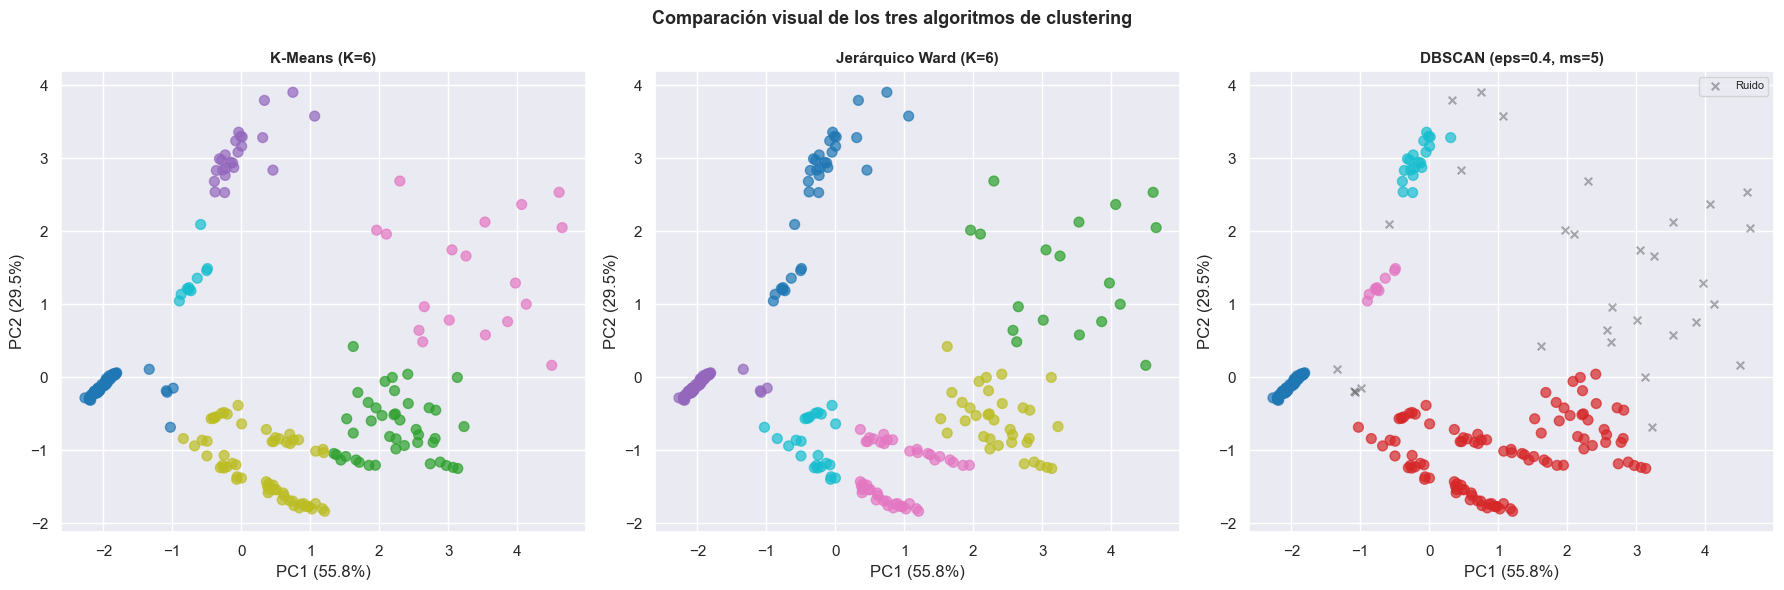

In [ ]:
# ============================================================
# COMPARACIÓN DE LOS TRES ALGORITMOS
# ============================================================

# Tabla comparativa de métricas
comparacion = pd.DataFrame({
    'Algoritmo': ['K-Means (K=6)', 'Jerárquico Ward (K=6)', 'DBSCAN (eps=0.4, ms=5)'],
    'Nº Clusters': [6, 6, 4],
    'Nº Ruido': [0, 0, 30],
    'Silhouette': [
        silhouette_score(X_pca, km_labels),
        silhouette_score(X_pca, hier_labels),
        silhouette_score(X_pca[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
    ],
    'Davies-Bouldin': [
        davies_bouldin_score(X_pca, km_labels),
        davies_bouldin_score(X_pca, hier_labels),
        davies_bouldin_score(X_pca[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
    ],
    'DBCV': ['-', '-', f'{dbcv_final:.4f}']
})

print("Tabla comparativa de algoritmos:")
display(comparacion)
print("\n NOTA: Silhouette y Davies-Bouldin de DBSCAN se calculan sobre 210/240 estrellas")
print("   (excluidos 30 puntos de ruido), lo que sesga al alza sus métricas respecto a K-Means y Jerárquico.")

# Gráfico comparativo visual — los tres resultados lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

algoritmos = [
    (km_labels, 'K-Means (K=6)'),
    (hier_labels, 'Jerárquico Ward (K=6)'),
    (dbscan_labels, 'DBSCAN (eps=0.4, ms=5)')
]

for ax, (labels, titulo) in zip(axes, algoritmos):
    mask_ruido = labels == -1
    mask_clusters = labels != -1
    
    if mask_ruido.sum() > 0:
        ax.scatter(X_pca[mask_ruido, 0], X_pca[mask_ruido, 1],
                   c='black', s=30, alpha=0.3, marker='x', label='Ruido')
    
    scatter = ax.scatter(X_pca[mask_clusters, 0], X_pca[mask_clusters, 1],
                         c=labels[mask_clusters], cmap='tab10',
                         s=50, alpha=0.7)
    
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    
    if mask_ruido.sum() > 0:
        ax.legend(fontsize=8)

plt.suptitle('Comparación visual de los tres algoritmos de clustering',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Discusión comparativa

| Algoritmo | Clusters | Ruido | Silhouette | Davies-Bouldin | DBCV |
|-----------|----------|-------|------------|----------------|------|
| K-Means (K=6) | 6 | 0 | 0.6488 | 0.5164 | - |
| Jerárquico Ward (K=6) | 6 | 0 | 0.6126 | 0.6148 | - |
| DBSCAN (eps=0.4, ms=5) | 4 | 30 | 0.6789 | 0.3890 | 0.6582 |

Los tres algoritmos revelan estructura clara en los datos, aunque con 
matices importantes:

**K-Means** obtiene el mejor balance entre métricas y número de clusters. 
Al forzar 6 grupos cubre todos los puntos sin excepciones y produce 
clusters compactos y bien separados. Es el más interpretable y el que 
mejor se alinea con la clasificación astronómica de 6 tipos estelares.

**Clustering Jerárquico** confirma la estructura de K-Means con métricas 
ligeramente inferiores. Su valor añadido es el dendrograma, que permite 
visualizar la jerarquía completa de fusiones y confirmar visualmente 
que K=6 es una partición natural de los datos.

**DBSCAN** obtiene las mejores métricas numéricas, pero hay que 
interpretar con cautela: al excluir 30 puntos como ruido, los clusters 
restantes son más puros, lo que infla artificialmente Silhouette y 
Davies-Bouldin. Su aportación más valiosa es identificar esos 30 puntos 
como casos atípicos difíciles de clasificar, información que los otros 
algoritmos no proporcionan. Sin embargo, al encontrar solo 4 clusters 
pierde granularidad respecto a la clasificación astronómica real.

## 5. Pipeline recomendado

Tras comparar los tres algoritmos se recomienda el siguiente pipeline:

**1. Limpieza**: normalización de la variable Color (minúsculas, sin guiones)  
**2. Codificación ordinal**: Color y Spectral_Class según orden físico real  
**3. Escalado**: StandardScaler sobre todas las variables  
**4. Reducción**: PCA con 2 componentes (85.3% varianza explicada)  
**5. Clustering**: K-Means con K=6 y n_init=10  

### Justificación

K-Means es el algoritmo recomendado por varias razones. Primero, produce 
exactamente 6 clusters, coherente con los 6 tipos estelares reconocidos 
astronómicamente. Segundo, clasifica la totalidad de las 240 estrellas 
sin dejar ninguna como ruido, lo cual es deseable cuando el objetivo es 
obtener una clasificación completa. Tercero, obtiene el mejor balance 
de métricas entre los algoritmos que asignan todos los puntos (Silhouette 
0.6488, Davies-Bouldin 0.5164). Finalmente, el clustering jerárquico 
confirma de forma independiente mediante el dendrograma que K=6 es una 
partición natural de estos datos, reforzando la elección.

DBSCAN, aunque obtiene buenas métricas, encuentra solo 4 clusters y 
deja un 12.5% de estrellas sin clasificar, lo que lo hace menos adecuado 
para el objetivo de clasificación completa de tipos estelares.

In [32]:
# ============================================================
# PIPELINE RECOMENDADO — K-MEANS K=6
# ============================================================

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=SEED)),
    ('kmeans', KMeans(n_clusters=6, random_state=SEED, n_init=10))
])

pipeline.fit(X)
pipeline_labels = pipeline.predict(X)

sil_pipe = silhouette_score(
    pipeline.named_steps['pca'].transform(
        pipeline.named_steps['scaler'].transform(X)
    ), pipeline_labels
)

print("Pipeline ejecutado correctamente ✓")
print(f"Silhouette Score: {sil_pipe:.4f}")
print(f"\nDistribución final de estrellas por cluster:")
for c, n in zip(*np.unique(pipeline_labels, return_counts=True)):
    print(f"  Cluster {c}: {n} estrellas")

Pipeline ejecutado correctamente ✓
Silhouette Score: 0.6488

Distribución final de estrellas por cluster:
  Cluster 0: 85 estrellas
  Cluster 1: 42 estrellas
  Cluster 2: 24 estrellas
  Cluster 3: 18 estrellas
  Cluster 4: 61 estrellas
  Cluster 5: 10 estrellas


## 6. Comparación con la clasificación astronómica

Se analizan las características medias de cada cluster obtenido con 
K-Means (pipeline recomendado) para identificar su correspondencia 
con los 6 tipos estelares reconocidos en astronomía.

In [33]:
# ============================================================
# COMPARACIÓN CON CLASIFICACIÓN ASTRONÓMICA
# ============================================================

# Añadimos las etiquetas al dataframe original
df_resultado = df_clean.copy()
df_resultado['Cluster'] = pipeline_labels

# Características medias por cluster (variables originales sin escalar)
cols_analisis = ['Temperature', 'L', 'R', 'A_M', 'Spectral_Class', 'Color']
medias = df_resultado.groupby('Cluster')[['Temperature', 'L', 'R', 'A_M']].mean().round(2)
modas = df_resultado.groupby('Cluster')[['Spectral_Class', 'Color']].agg(lambda x: x.value_counts().index[0])

resumen = pd.concat([medias, modas], axis=1)
resumen['N_estrellas'] = df_resultado.groupby('Cluster').size()

print("Características medias por cluster:")
display(resumen)

Características medias por cluster:


,Temperature,L,R,A_M,Spectral_Class,Color,N_estrellas
Cluster,,,,,,,
0,3261.13,0.02,0.26,14.59,M,red,85
1,21793.36,203221.86,52.88,-5.55,O,blue,42
2,3782.38,245541.67,1391.88,-9.92,M,red,24
3,24015.89,512365.61,1105.39,-8.73,O,blue,18
4,12608.90,136.17,1.27,8.32,B,blue white,61
5,3466.80,206600.00,129.50,-6.80,M,red,10


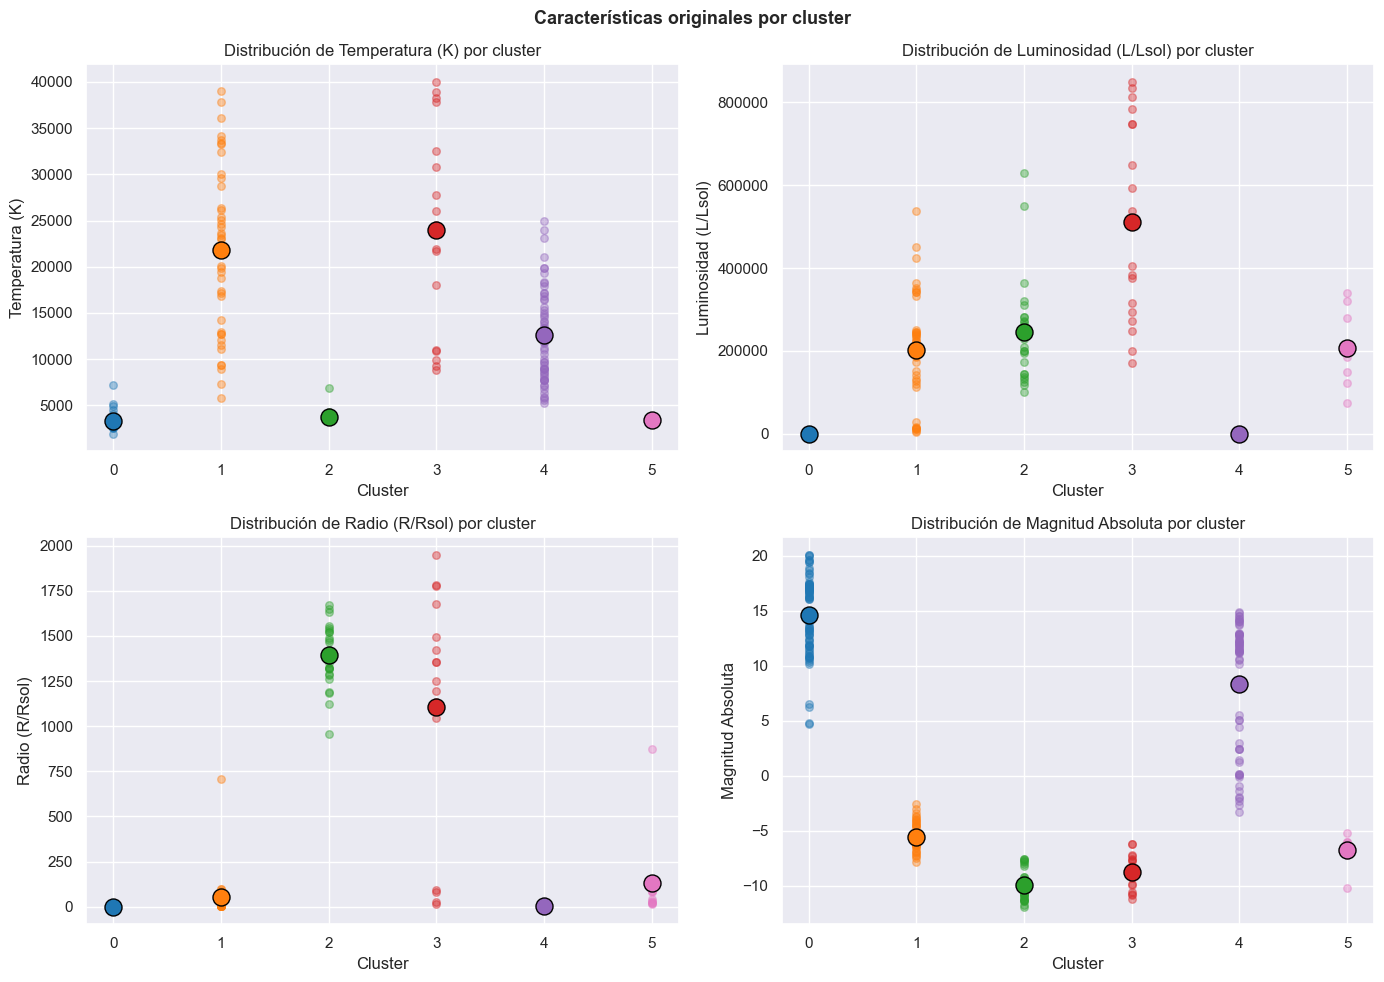

In [34]:
# Visualización de clusters con características originales
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables = [('Temperature', 'Temperatura (K)'), 
             ('L', 'Luminosidad (L/Lsol)'),
             ('R', 'Radio (R/Rsol)'), 
             ('A_M', 'Magnitud Absoluta')]

colores = plt.cm.tab10(np.linspace(0, 0.6, 6))

for ax, (var, label) in zip(axes.flatten(), variables):
    for cluster in range(6):
        datos = df_resultado[df_resultado['Cluster'] == cluster][var]
        ax.scatter([cluster]*len(datos), datos, 
                  alpha=0.4, s=30, color=colores[cluster])
        ax.scatter(cluster, datos.mean(), 
                  s=150, color=colores[cluster], 
                  edgecolors='black', zorder=5)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(label)
    ax.set_title(f'Distribución de {label} por cluster')
    ax.set_xticks(range(6))

plt.suptitle('Características originales por cluster', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Comparación con la clasificación astronómica

### Correspondencia entre clusters y tipos estelares

Analizando las características medias de cada cluster y comparándolas 
con la tabla de tipos estelares reconocidos en astronomía:

| Cluster | Temp (K) | L | R | A_M | Tipo astronómico |
|---------|----------|---|---|-----|-----------------|
| 0 | 3261 | 0.02 | 0.26 | +14.59 | **Enana roja** |
| 1 | 21793 | 203.221 | 52.88 | -5.55 | **Supergigante** |
| 2 | 3782 | 245.541 | 1391.88 | -9.92 | **Supergigante/Hipergigante roja** (T baja, radio extremo)** |
| 3 | 24015 | 512.365 | 1105.39 | -8.73 | **Hipergigante caliente** |
| 4 | 12608 | 136.17 | 1.27 | +8.32 | **Secuencia principal** |
| 5 | 3466 | 206.600 | 129.50 | -6.80 | **Gigante roja** |

### Discusión

La correspondencia entre los clusters obtenidos y los tipos estelares 
astronómicos es notable, especialmente considerando que el algoritmo 
no ha recibido ninguna etiqueta durante el entrenamiento.

**Cluster 0** agrupa 85 estrellas con temperatura baja (~3.261K), 
luminosidad y radio muy pequeños y magnitud absoluta alta (+14.59). 
Corresponde claramente a las **enanas rojas**, el tipo estelar más 
abundante del dataset y del universo.

**Cluster 4** agrupa 61 estrellas con temperatura media (~12.608K), 
luminosidad moderada y radio cercano al solar (1.27). La magnitud 
absoluta positiva (+8.32) indica estrellas no especialmente brillantes. 
Corresponde a estrellas de la **secuencia principal**, el grupo más 
heterogéneo que incluye estrellas tipo sol y enanas blancas.

**Cluster 1** agrupa 42 estrellas con alta temperatura (~21.793K), 
luminosidad muy elevada y radio grande (52.88). Corresponde a 
**supergigantes**, coherente con la tabla astronómica.

**Cluster 2** agrupa 24 estrellas con temperatura baja pero radio 
extraordinariamente grande (1391.88) y luminosidad altísima. 
Corresponde a **supergigantes/hipergigantes rojas**. Su temperatura (~3.782K) es más baja que la hipergigante de referencia astronómica (~11.000K), pero el radio extremo (1.391 R☉) y la magnitud muy negativa (-9.92) la sitúan en la frontera entre supergigante roja e hipergigante.

**Cluster 3** agrupa 18 estrellas con las mayores luminosidades y 
radios del dataset junto a magnitudes muy negativas (-8.73), 
indicando objetos extremadamente brillantes. Corresponde a 
**hipergigantes calientes**.

**Cluster 5** es el más pequeño (10 estrellas) con temperatura baja, 
radio grande y magnitud negativa. Corresponde a **gigantes rojas**, 
un tipo intermedio entre enanas y supergigantes que el algoritmo 
ha separado correctamente del resto.

### Conclusión

El algoritmo K-Means aplicado sobre las componentes PCA ha recuperado 
de forma no supervisada una clasificación muy similar a la establecida 
por la astronomía. Los 6 clusters obtenidos tienen una correspondencia 
clara con los 6 tipos estelares de la tabla, lo que valida tanto la 
elección del algoritmo como el preprocesado aplicado. Las pequeñas 
discrepancias entre clusters adyacentes (como hipergigantes vs 
supergigantes) son esperables dado que estos tipos comparten 
características físicas similares y sus fronteras no son absolutas 
ni en astronomía ni en los datos.

**Declaración de uso de IA**

Para la realización de esta práctica hemos utilizado herramientas de IA generativa (principalmente Claude y Gemini) como apoyo para agilizar las tareas más mecánicas. Nos han servido de ayuda para escribir código repetitivo (como la creación de gráficos o el formateo de datos), maquetar las tablas y darle formato al documento. También las usamos para pulir la redacción de nuestras ideas y como una especie de "corrector" al final del trabajo, lo que nos ayudó a detectar algunos despistes que luego revisamos y corregimos.

Además de para la parte práctica, la IA ha sido una gran herramienta de estudio para entender mejor la teoría detrás de la asignatura. La hemos utilizado como una especie de "profesor particular"; cuando algún concepto matemático o el funcionamiento de un algoritmo se nos atascaba, le pedíamos que nos lo explicara con otras palabras o con ejemplos más sencillos. Esto nos ayudó muchísimo a afianzar la base teórica antes de ponernos a programar.

Aun así, queremos destacar que la IA ha funcionado princpalmente como un asistente para ahorrarnos tiempo. Todas las decisiones clave del trabajo, como la elección de hiperparámetros, la selección de los algoritmos y, sobre todo, la interpretación crítica de los datos astronómicos, son cien por cien nuestras. Básicamente, hemos usado la tecnología para la presentación y el código rutinario, permitiéndonos centrar nuestro esfuerzo en entender y analizar los resultados del clustering.